# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [2]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Luis Santoyo"            # Tu nombre completo
MATRICULA = "81377"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Luis Santoyo
Matrícula: 81377
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [23]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


/Users/lizette/Coding/bigdata/examen1parcial/.venv/bin/python


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [10]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [11]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [12]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [13]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*los nulos en code no son datos faltantes, son 33 regiones agregados sin código ISO. El rango de años va de 2000 a 2024, sin nulos en year ni en valor. La variable valor es de tipo float64 y representa un conteo absoluto de personas subalimentadas; está muy sesgada a la derecha, lo cual tiene sentido porque es un valor absoluto no normalizado por población: países muy poblados dominan el extremo superior.*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [42]:
# Pregunta 1
df_paises = df[df[config["filtro_paises"]].notnull() & (df["entity"] != "World")]

n_paises = df_paises["entity"].nunique()
print("Países distintos:", n_paises)

ultimo_valor_por_pais = df_paises.sort_values("year").drop_duplicates("entity", keep="last")

top_10 = ultimo_valor_por_pais.sort_values("valor", ascending=False).head(10)
bottom_10 = ultimo_valor_por_pais.sort_values("valor", ascending=True).head(10)

print("\nTop 10 - mayor valor:")
print(top_10[["entity", "year", "valor"]])

print("\nTop 10 - menor valor:")
print(bottom_10[["entity", "year", "valor"]])


Países distintos: 139

Top 10 - mayor valor:
                            entity  year        valor
1360                         India  2023  172100000.0
2260                       Nigeria  2023   45400000.0
2420                      Pakistan  2023   40900000.0
784   Democratic Republic of Congo  2023   40700000.0
640                          China  2009   38500000.0
1057                      Ethiopia  2023   25400000.0
1511                         Kenya  2023   20400000.0
221                     Bangladesh  2023   17900000.0
1383                     Indonesia  2023   17700000.0
3124                      Tanzania  2023   13400000.0

Top 10 - menor valor:
                      entity  year     valor
314   Bosnia and Herzegovina  2003  100000.0
1011                 Estonia  2004  100000.0
3322                 Uruguay  2004  100000.0
1611                  Latvia  2004  100000.0
2054              Montenegro  2006  100000.0
167                  Armenia  2009  100000.0
761                   C

**Interpretación:**

*El DataFrame tiene paises distintos, Siendo el de Mayor valor la India y el de menor valor Bosnia and Herzegovina entre otros.*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [46]:
# Pregunta 2
df_Mexico = df_paises[df_paises["entity"] == "Mexico"]
print("México:")
print(df_Mexico[["entity", "year", "valor"]])
print("\n")
df_China = df_paises[df_paises["entity"] == "China"]
print("China:")
print(df_China[["entity", "year", "valor"]])


México:
      entity  year      valor
1964  Mexico  2001  2800000.0
1965  Mexico  2002  3300000.0
1966  Mexico  2003  3900000.0
1967  Mexico  2004  4300000.0
1968  Mexico  2005  4200000.0
1969  Mexico  2006  4000000.0
1970  Mexico  2007  4000000.0
1971  Mexico  2008  4400000.0
1972  Mexico  2009  4600000.0
1973  Mexico  2010  4600000.0
1974  Mexico  2011  4400000.0
1975  Mexico  2012  4500000.0
1976  Mexico  2013  4400000.0
1977  Mexico  2014  4500000.0
1978  Mexico  2015  4400000.0
1979  Mexico  2016  4500000.0
1980  Mexico  2017  4600000.0
1981  Mexico  2018  4500000.0
1982  Mexico  2019  4300000.0
1983  Mexico  2020  3900000.0
1984  Mexico  2021  3800000.0
1985  Mexico  2022  3600000.0
1986  Mexico  2023  3500000.0


China:
    entity  year        valor
632  China  2001  127300000.0
633  China  2002  120200000.0
634  China  2003  111300000.0
635  China  2004  101500000.0
636  China  2005   90600000.0
637  China  2006   78800000.0
638  China  2007   65300000.0
639  China  2008   5170

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [53]:
# Pregunta 3
df_India = df_paises[df_paises["entity"] == "India"]
df_Mexico = df_paises[df_paises["entity"] == "Mexico"]
df_Nigeria = df_paises[df_paises["entity"] == "Nigeria"]
df_Croacia = df_paises[df_paises["entity"] == "Croatia"]
df_Brazil = df_paises[df_paises["entity"] == "Brazil"]

valor_India = df_India.sort_values("year")["valor"].iloc[-1]
valor_Mexico = df_Mexico.sort_values("year")["valor"].iloc[-1]
valor_Nigeria = df_Nigeria.sort_values("year")["valor"].iloc[-1]
valor_Croacia = df_Croacia.sort_values("year")["valor"].iloc[-1]
valor_Brazil = df_Brazil.sort_values("year")["valor"].iloc[-1]

print("India:", valor_India)
print("Mexico:", valor_Mexico)
print("Nigeria:", valor_Nigeria)
print("Croatia:", valor_Croacia)
print("Brazil:", valor_Brazil)


India: 172100000.0
Mexico: 3500000.0
Nigeria: 45400000.0
Croatia: 100000.0
Brazil: 6700000.0


**Interpretación:**

*De los 5 paises que escogí India tiene un indice de desnutrición mas alto con 172´100,000.0 ante Croacia que tiene un indice mas bajo con 100,000.0,teniendo una diferencia entre ellos de 172´000,000.0*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [52]:
# Pregunta 4
# Pregunta 4
df_Mexico = df_paises[df_paises["entity"] == "Mexico"]
df_Colombia = df_paises[df_paises["entity"] == "Colombia"]
df_Argentina = df_paises[df_paises["entity"] == "Argentina"]

df_China = df_paises[df_paises["entity"] == "China"]
df_Thailand = df_paises[df_paises["entity"] == "Thailand"]  # sustituye a Japan (sin datos en este dataset)
df_Vietnam = df_paises[df_paises["entity"] == "Vietnam"]

# Valor mas reciente de cada pais
valor_Mexico = df_Mexico.sort_values("year")["valor"].iloc[-1]
valor_Colombia = df_Colombia.sort_values("year")["valor"].iloc[-1]
valor_Argentina = df_Argentina.sort_values("year")["valor"].iloc[-1]

valor_China = df_China.sort_values("year")["valor"].iloc[-1]
valor_Thailand = df_Thailand.sort_values("year")["valor"].iloc[-1]
valor_Vietnam = df_Vietnam.sort_values("year")["valor"].iloc[-1]

promedio_latam = (valor_Mexico + valor_Colombia + valor_Argentina) / 3
promedio_asia = (valor_China + valor_Thailand + valor_Vietnam) / 3

print("Mexico:", valor_Mexico)
print("Colombia:", valor_Colombia)
print("Argentina:", valor_Argentina)
print("Promedio Latinoamerica:", promedio_latam)

print("\nChina:", valor_China)
print("Thailand:", valor_Thailand)
print("Vietnam:", valor_Vietnam)
print("Promedio Asia:", promedio_asia)

print("\nDiferencia de promedios: ", promedio_asia - promedio_latam)




Mexico: 3500000.0
Colombia: 2000000.0
Argentina: 1500000.0
Promedio Latinoamerica: 2333333.3333333335

China: 38500000.0
Thailand: 3300000.0
Vietnam: 5300000.0
Promedio Asia: 15700000.0

Diferencia de promedios:  13366666.666666666


**Interpretación:**

*De los paises seleccionados de latinuameria y de asia segun lo mostrado, los paises Asiaticos tienen in indice mayor de desnutrición ante los latinoamericanos, teniendo una diferencia aproximada de 13´366,666.66*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [ ]:
# Pregunta 5
df_Argentina = df_paises[df_paises["entity"] == "Argentina"]
print("Argentina:")
print(df_Argentina[["entity", "year", "valor"]])

promedio_Argentina = df_Argentina["valor"].mean()
print("Promedio de Argentina:", promedio_Argentina)


Argentina:
        entity  year      valor
136  Argentina  2001  1100000.0
137  Argentina  2002  1400000.0
138  Argentina  2003  1700000.0
139  Argentina  2004  1500000.0
140  Argentina  2005  1400000.0
141  Argentina  2006  1300000.0
142  Argentina  2007  1300000.0
143  Argentina  2008  1300000.0
144  Argentina  2009  1400000.0
145  Argentina  2010  1500000.0
146  Argentina  2011  1600000.0
147  Argentina  2012  1500000.0
148  Argentina  2013  1400000.0
149  Argentina  2014  1200000.0
150  Argentina  2015  1300000.0
151  Argentina  2016  1400000.0
152  Argentina  2017  1600000.0
153  Argentina  2018  1600000.0
154  Argentina  2019  1600000.0
155  Argentina  2020  1600000.0
156  Argentina  2021  1500000.0
157  Argentina  2022  1500000.0
158  Argentina  2023  1500000.0
Promedio de Argentina: 1443478.2608695652


**Interpretación:**

*El país que yo eleji fue argentina, este tuvo un indice de desnutrición relativamente constante a lo largo del los años ya empezo con un valor ralativamente bajo comparado con el último de 1´100,000.0, después fue cuando subio a 1´400,000.0 subiendo 300,000 en solo un año, posteriormente subiendo otros 200,000 en el año 2003 siendo este su indice mas alto. A lo largo de todos los años fue promediando de 1.2M a 1.6 con una media de 1443478.2608695652 entre los años 2001-2023*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [56]:
# Pregunta 6
df_Mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

primer_valor = df_Mexico["valor"].iloc[0]
primer_anio = df_Mexico["year"].iloc[0]

ultimo_valor = df_Mexico["valor"].iloc[-1]
ultimo_anio = df_Mexico["year"].iloc[-1]

cambio_porcentual = (ultimo_valor - primer_valor) / primer_valor * 100

print(f"Mexico en {primer_anio}: {primer_valor}")
print(f"Mexico en {ultimo_anio}: {ultimo_valor}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")


Mexico en 2001: 2800000.0
Mexico en 2023: 3500000.0
Cambio porcentual: 25.00%


**Interpretación:**

*El indicador de desnutrición en México muestra un incremento relativo de aproximadamente un 25% en 2001-2023, esto podria deberse al crecimiento de la población de país en este periodo, a su vez a las crisis económicas que se han sufrido y afectado al acceso de alimentos.*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [61]:
# Pregunta 7
anio_reciente = df_paises["year"].max()
print("Año más reciente:", anio_reciente)

df_anio_reciente = df_paises[df_paises["year"] == anio_reciente]

valores = df_anio_reciente["valor"].to_numpy()
valores = valores[~np.isnan(valores)]  # quitar NaN por si hay

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print("Cantidad de países considerados:", len(valores))
print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", desviacion)


Año más reciente: 2023
Cantidad de países considerados: 105
Media: 5884761.904761905
Mediana: 1600000.0
Desviación estándar: 18150375.994806126


**Interpretación:**

*Se nota que la media es bastante más alta que la mediana, lo que significa que la mayoría de los países tienen cifras relativamente chicas, pero unos cuantos países con muchísima población como India que tienen números tan grandes que "jalan" el promedio para arriba. Además, la desviación estándar es enorme comparada con la media, lo cual nos confirma que hay mucha diferencia entre ciertos paises.*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

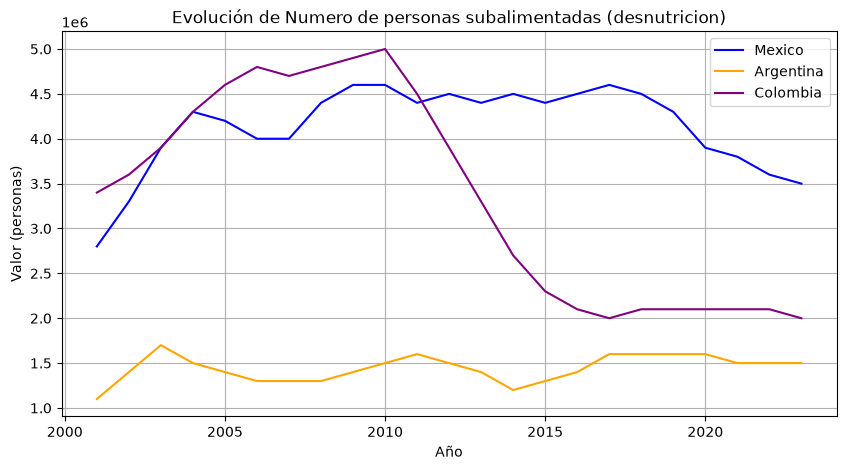

In [62]:
# Pregunta 8
plt.figure(figsize=(10, 5))

plt.plot(df_Mexico["year"], df_Mexico["valor"], label="Mexico", color="blue")
plt.plot(df_Argentina["year"], df_Argentina["valor"], label="Argentina", color="orange")
plt.plot(df_Colombia["year"], df_Colombia["valor"], label="Colombia", color="purple")

plt.title(f"Evolución de {config['descripcion']}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.grid(True)
plt.legend()

plt.show()

**Interpretación:**

*Los tres paises que escogí fueron México, Argentina y Colombia. Lo que presibo es que México empezo con un indice relativamente bajo con su valor final aunque tuvo unos incrementos vastantes altos por los años 2010-2020, de Argentina se nota que tuvieron un indice moderado osilando entre los 1.1M y 1.7M siendo el mas bajo de los 3, Y por último Colombia empezo con aporximadamente 3.4M y tuvo un incremento por los años 2005-2010 pero al final tuvo una caida bastante favorable llegando a aproximadamente 2M de personas.*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

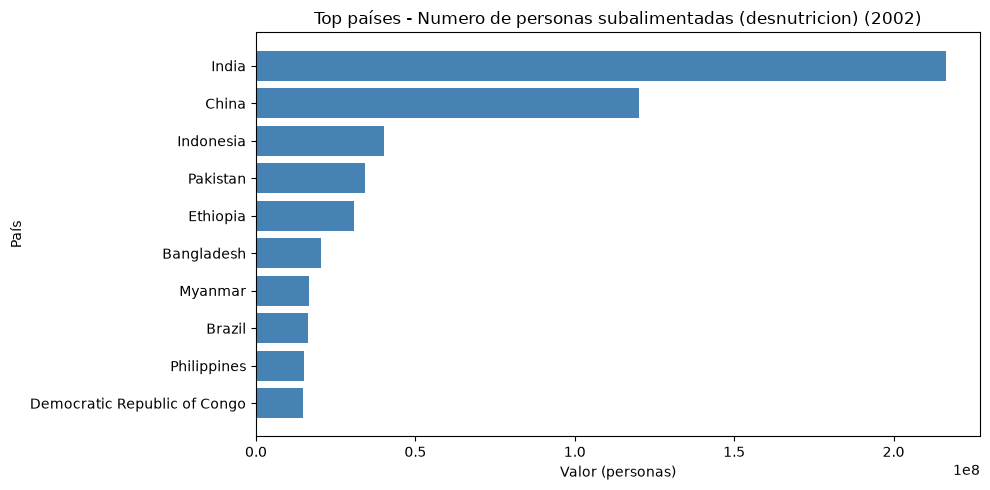

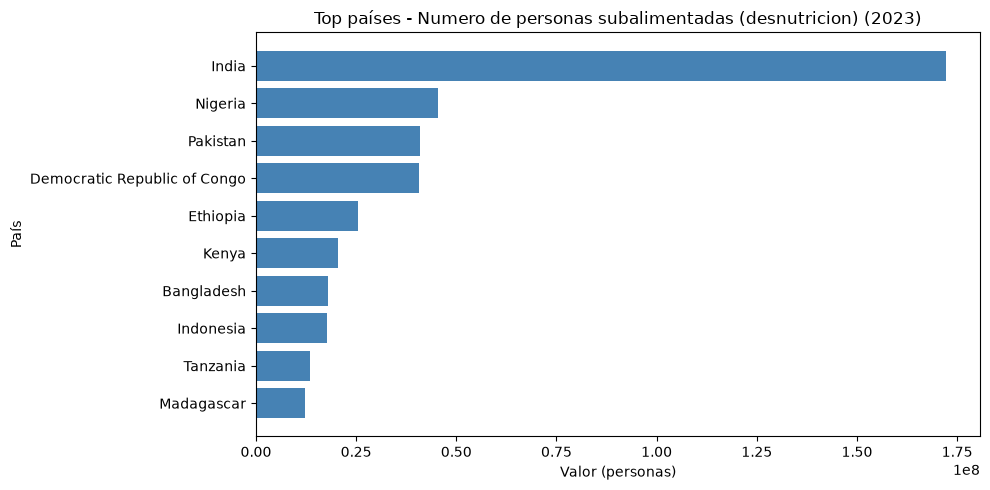

In [66]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull() & (df["entity"] != "World")]

anio_consultado = 2002

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()
print("\n\n")
anio_consultado = 2023

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


**Interpretación:**

*India y Pakistán se mantienen entre los primeros lugares en ambos años, pero hay cambios notorios: China, que en 2002 era el #2 con aproximadamente 120M, ya no aparece en el top 10 de 2023. Nigeria y República Democrática del Congo subieron mucho, entrando al top con aproximadamente 45.3M y 40.6M respectivamente en 2023 (en 2002 ni siquiera estaban en el top 10). India bajó de 216.3M a 172.1M, una mejora considerable, pero sigue siendo, por mucho, el país con más personas subalimentadas. En general, el problema se desplazó de Asia hacia África subsahariana entre 2002 y 2023.*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Trabajé con el dataset de personas subalimentadas (desnutrición), que tiene datos de 139 países entre 2000 y 2023. Lo que más noté es que unos cuantos países (India, China, Nigeria) tienen cifras muchísimo más altas que el resto, lo que hace que el promedio no sea muy representativo. También vi que entre 2002 y 2023 el problema se movió un poco: China ya no aparece en los primeros lugares, pero países africanos como Nigeria y RD del Congo subieron bastante.

La principal limitación es que los números son absolutos, no están ajustados por población, entonces un país grande siempre se va a ver "peor" aunque en proporción no lo esté tanto. Además no todos los países reportan cada año, así que hay huecos en la información.

Si tuviera más tiempo, me gustaría calcular el porcentaje de población subalimentada en vez del número total, para poder comparar mejor entre países grandes y chicos.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
